In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [6]:
MODEL_PATH = "../models/resnet50_best.keras"

model = load_model(MODEL_PATH)

print("✅ Model loaded")
print("Input shape :", model.input_shape)
print("Output shape:", model.output_shape)

✅ Model loaded
Input shape : (None, 224, 224, 3)
Output shape: (None, 5)


In [7]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,165,201 (96.00 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 1,051,660 (4.01 MB)

In [8]:
base_model = model.get_layer("resnet50")

print("Base model:", base_model.name)
print("Number of layers:", len(base_model.layers))

print("\nLast 10 layers:")
for layer in base_model.layers[-10:]:
    print(f"{layer.name:30} {layer.__class__.__name__}")

Base model: resnet50
Number of layers: 175

Last 10 layers:
conv5_block3_1_conv            Conv2D
conv5_block3_1_bn              BatchNormalization
conv5_block3_1_relu            Activation
conv5_block3_2_conv            Conv2D
conv5_block3_2_bn              BatchNormalization
conv5_block3_2_relu            Activation
conv5_block3_3_conv            Conv2D
conv5_block3_3_bn              BatchNormalization
conv5_block3_add               Add
conv5_block3_out               Activation


In [9]:
for i, layer in enumerate(model.layers):
    print(f"{i}: {layer.name} --> {layer.__class__.__name__}")

0: resnet50 --> Functional
1: global_average_pooling2d_1 --> GlobalAveragePooling2D
2: dropout_2 --> Dropout
3: dense_2 --> Dense
4: dropout_3 --> Dropout
5: dense_3 --> Dense


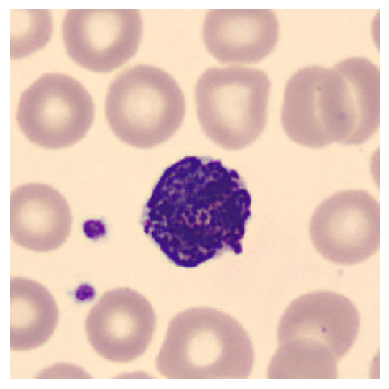

In [10]:
IMG_PATH = "../dataset/basophil/BA_100102.jpg"

img = image.load_img(IMG_PATH, target_size=(224,224))

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

plt.imshow(img)
plt.axis("off")
plt.show()

In [13]:
import os

DATASET_PATH = "../dataset"

class_names = sorted([
    folder
    for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print(class_names)

['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']


In [14]:
prediction = model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction)

confidence = float(np.max(prediction))

print("Predicted class :", class_names[predicted_index])
print("Confidence      :", confidence)

Predicted class : myeloblast
Confidence      : 0.9873570203781128


In [15]:
prediction = model.predict(img_array, verbose=0)[0]

indices = np.argsort(prediction)[::-1]

print("Top Predictions")
print("-"*35)

for i in indices:
    print(f"{class_names[i]:20s} {prediction[i]*100:.2f}%")

Top Predictions
-----------------------------------
myeloblast           98.74%
erythroblast         1.26%
monocyte             0.00%
seg_neutrophil       0.00%
basophil             0.00%


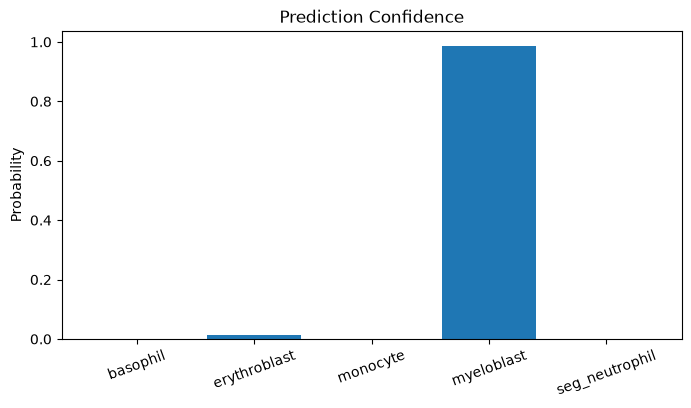

In [16]:
plt.figure(figsize=(8,4))

plt.bar(class_names, prediction)

plt.title("Prediction Confidence")
plt.ylabel("Probability")

plt.xticks(rotation=20)

plt.show()

In [17]:
predicted_index = np.argmax(prediction)

print("="*50)
print("MODEL EXPLANATION")
print("="*50)

print(f"Predicted Cell Type : {class_names[predicted_index]}")
print(f"Confidence          : {prediction[predicted_index]*100:.2f}%")

if prediction[predicted_index] > 0.95:
    print("\nThe model is highly confident about this prediction.")
elif prediction[predicted_index] > 0.80:
    print("\nThe model is moderately confident about this prediction.")
else:
    print("\nThe model is uncertain about this prediction.")

MODEL EXPLANATION
Predicted Cell Type : myeloblast
Confidence          : 98.74%

The model is highly confident about this prediction.


In [18]:
results = {
    "Predicted Class": class_names[predicted_index],
    "Confidence": float(prediction[predicted_index]),
    "All Probabilities": prediction.tolist()
}

print(results)

{'Predicted Class': 'myeloblast', 'Confidence': 0.9873570203781128, 'All Probabilities': [1.1092981644367228e-08, 0.012625976465642452, 1.413351947121555e-05, 0.9873570203781128, 2.821915131789865e-06]}


In [19]:
import sys
!"{sys.executable}" -m pip install tf-keras-vis


   -------------------- ------------------- 1/2 [tf-keras-vis]
   ---------------------------------------- 2/2 [tf-keras-vis]



In [20]:
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

print("✅ tf-keras-vis imported successfully")

✅ tf-keras-vis imported successfully


In [2]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dropout,
    Dense
)
from tensorflow.keras.models import Model

# Input layer
base_model = ResNet50(
    weights=None,          # We'll load trained weights from your model
    include_top=False,
    input_shape=(224,224,3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.2)(x)
outputs = Dense(5, activation="softmax")(x)

gradcam_model = Model(
    inputs=base_model.input,
    outputs=outputs
)

print("✅ Functional model created")

✅ Functional model created


In [4]:
from tensorflow.keras.models import load_model

MODEL_PATH = "../models/resnet50_best.keras"

model = load_model(MODEL_PATH)

print("✅ Sequential model loaded")

✅ Sequential model loaded


In [5]:
gradcam_model.set_weights(model.get_weights())

print("✅ Weights copied successfully")

✅ Weights copied successfully
